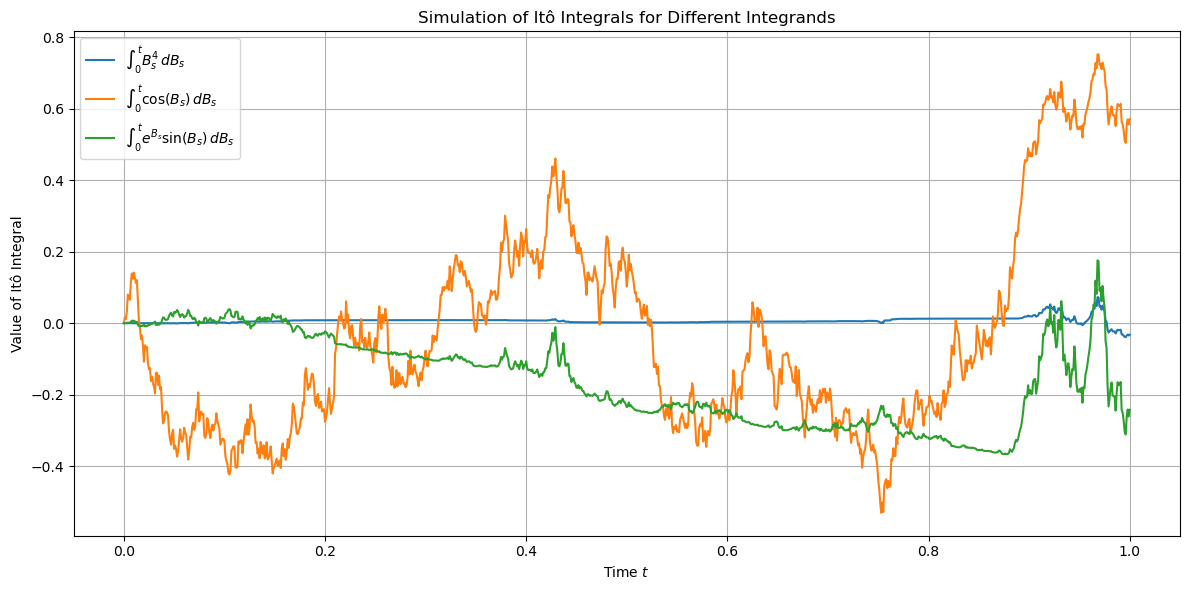

Final values of the Itô integrals:
∫ B_s^4 dB_s ≈ -0.0323
∫ cos(B_s) dB_s ≈ 0.5701
∫ e^{B_s} sin(B_s) dB_s ≈ -0.2423


In [22]:


import numpy as np
import matplotlib.pyplot as plt

# Simulation parameters

T = 1.0         # Time horizon
N = 1000        # Number of time steps
dt = T / N      # Time step
t = np.linspace(0, T, N + 1)  # Time grid

np.random.seed(42)  # Ensure reproducibility

# Simulate Brownian motion

dB = np.sqrt(dt) * np.random.randn(N)     # Brownian increments ~ N(0, dt)
B = np.concatenate([[0], np.cumsum(dB)])  # B_t as cumulative sum of dB


# Itô integrals to simulate:
# ∫ B_s^4 dB_s
# ∫ cos(B_s) dB_s
# ∫ e^{B_s} sin(B_s) dB_s

ito_b4 = np.zeros(N + 1)
ito_cos = np.zeros(N + 1)
ito_exp_sin = np.zeros(N + 1)

for i in range(1, N + 1):
    ito_b4[i] = ito_b4[i - 1] + B[i - 1]**4 * dB[i - 1]
    ito_cos[i] = ito_cos[i - 1] + np.cos(B[i - 1]) * dB[i - 1]
    ito_exp_sin[i] = ito_exp_sin[i - 1] + np.exp(B[i - 1]) * np.sin(B[i - 1]) * dB[i - 1]


plt.figure(figsize=(12, 6))
plt.plot(t, ito_b4, label=r"$\int_0^t B_s^4 \, dB_s$")
plt.plot(t, ito_cos, label=r"$\int_0^t \cos(B_s) \, dB_s$")
plt.plot(t, ito_exp_sin, label=r"$\int_0^t e^{B_s} \sin(B_s) \, dB_s$")
plt.title("Simulation of Itô Integrals for Different Integrands")
plt.xlabel("Time $t$")
plt.ylabel("Value of Itô Integral")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

print("Final values of the Itô integrals:")
print(f"∫ B_s^4 dB_s ≈ {ito_b4[-1]:.4f}")
print(f"∫ cos(B_s) dB_s ≈ {ito_cos[-1]:.4f}")
print(f"∫ e^{{B_s}} sin(B_s) dB_s ≈ {ito_exp_sin[-1]:.4f}")


# All three integrals are Itô integrals and are thus martingales.
# However, they exhibit very different behavior depending on the integrand:
#
# - ∫ B_s^4 dB_s: grows rapidly and can be unstable due to large powers of B.
# - ∫ cos(B_s) dB_s: remains bounded and oscillatory, centered around zero.
# - ∫ e^{B_s} sin(B_s) dB_s: exhibits chaotic and amplified behavior due to the exponential.


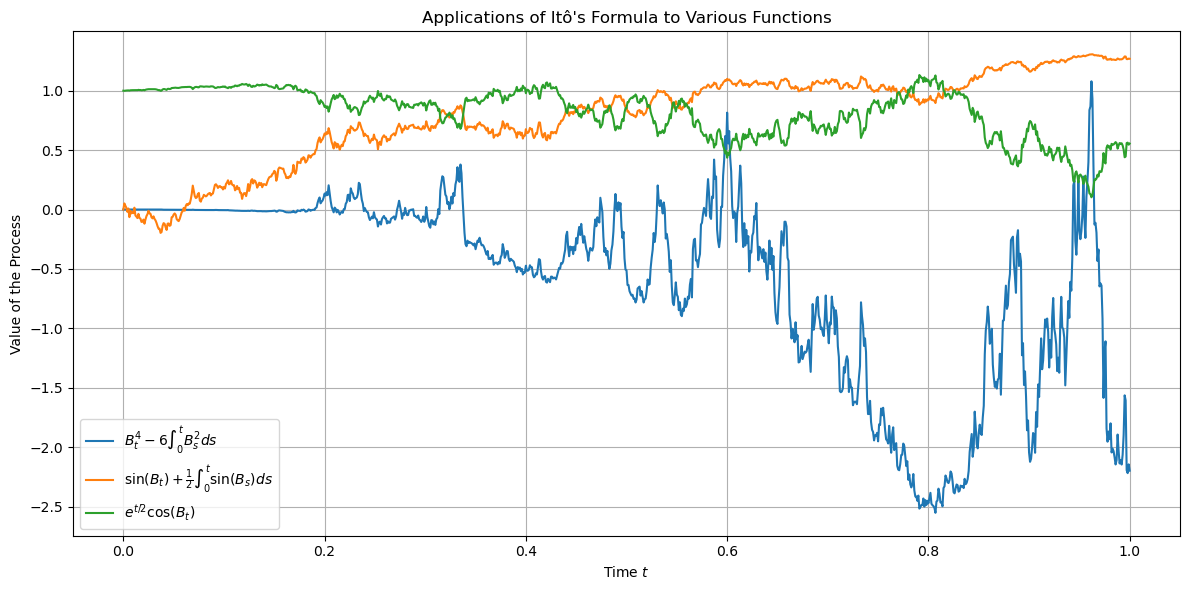

In [26]:
import numpy as np
import matplotlib.pyplot as plt

# Simulation parameters
T = 1.0        # Time horizon
N = 1000       # Number of time steps
dt = T / N     # Step size
t = np.linspace(0, T, N + 1)  # Time vector with N+1 points including t=0

#BM
np.random.seed(1)  
dB = np.sqrt(dt) * np.random.randn(N)        # Increments ~ N(0, dt)
B = np.concatenate([[0], np.cumsum(dB)])     # B_t from B_0 = 0

# --- Function 1: X_t = B_t^4 - 6 ∫ B_s^2 ds ---
# B**4 is of size (1001,)
integral1 = np.concatenate([[0], np.cumsum(B[:-1]**2 * dt)])
X1 = B**4 - 6 * integral1

# --- Function 2: X_t = sin(B_t) + 0.5 ∫ sin(B_s) ds ---
integral2 = np.concatenate([[0], np.cumsum(np.sin(B[:-1]) * dt)])
X2 = np.sin(B) + 0.5 * integral2

# --- Function 3: X_t = e^{t/2} * cos(B_t) ---
X3 = np.exp(t / 2) * np.cos(B)


plt.figure(figsize=(12, 6))
plt.plot(t, X1, label=r"$B_t^4 - 6 \int_0^t B_s^2 ds$")
plt.plot(t, X2, label=r"$\sin(B_t) + \frac{1}{2} \int_0^t \sin(B_s) ds$")
plt.plot(t, X3, label=r"$e^{t/2} \cos(B_t)$")
plt.title("Applications of Itô's Formula to Various Functions")
plt.xlabel("Time $t$")
plt.ylabel("Value of the Process")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()



#  The process B_t^4 - 6 ∫ B_s^2 ds exhibits rapid, unbounded growth—this is due to the dominant B_t^4 term.

#  The process sin(B_t) + (1/2) ∫ sin(B_s) ds remains bounded and oscillatory, driven by the periodic nature of sine.

#The process e^{t/2} * cos(B_t) shows oscillations with exponentially increasing amplitude, reflecting the influence of e^{t/2}.

